# Análisis Exploratorio de Datos (EDA) — Galaxy Zoo 2

Este notebook realiza el análisis exploratorio y preprocesamiento del catálogo
Galaxy Zoo 2, generando un dataset etiquetado de galaxias en 4 clases morfológicas:

- **Elliptical**: Galaxias suaves, sin estructura de disco (score 'smooth' alto)
- **Spiral**: Disco con brazos espirales visibles
- **Edge-on**: Disco visto de canto (inclination ~90°)
- **Merger**: Par de galaxias en proceso de fusión

**Flujo del análisis:**
1. Cargar etiquetas y metadatos del catálogo SDSS
2. Explorar distribución de clasificaciones voluntarias
3. Aplicar umbrales de confianza (scores debiased) para extraer clases puras
4. Balancear dataset y exportar como gz2_labels_clean.csv

In [20]:
# Importar librerías fundamentales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import os

# Configurar pandas para mejor visualización en Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

## 1. Carga de Datos — Galaxy Zoo 2 (SDSS)

Cargamos dos CSVs:
- **labels.csv**: Clasificaciones morfológicas con scores de confianza (debiased)
- **filemapping.csv**: Mapeo entre IDs del SDSS y nombres de archivo de imagen

In [21]:
# Cargar clasificaciones morfológicas de Galaxy Zoo 2
# Columna clave: gz2class (tipo morfológico) y scores debiased por cada categoría
labels = pd.read_csv('../data/labels.csv')
labels.head(10)

,specobjid,dr8objid,dr7objid,ra,dec,rastring,decstring,sample,gz2class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,t01_smooth_or_features_a01_smooth_weight,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a01_smooth_weighted_fraction,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a01_smooth_flag,t01_smooth_or_features_a02_features_or_disk_count,t01_smooth_or_features_a02_features_or_disk_weight,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a02_features_or_disk_weighted_fraction,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a02_features_or_disk_flag,t01_smooth_or_features_a03_star_or_artifact_count,t01_smooth_or_features_a03_star_or_artifact_weight,t01_smooth_or_features_a03_star_or_artifact_fraction,t01_smooth_or_features_a03_star_or_artifact_weighted_fraction,t01_smooth_or_features_a03_star_or_artifact_debiased,t01_smooth_or_features_a03_star_or_artifact_flag,t02_edgeon_a04_yes_count,t02_edgeon_a04_yes_weight,t02_edgeon_a04_yes_fraction,t02_edgeon_a04_yes_weighted_fraction,t02_edgeon_a04_yes_debiased,t02_edgeon_a04_yes_flag,t02_edgeon_a05_no_count,t02_edgeon_a05_no_weight,t02_edgeon_a05_no_fraction,t02_edgeon_a05_no_weighted_fraction,t02_edgeon_a05_no_debiased,t02_edgeon_a05_no_flag,t03_bar_a06_bar_count,t03_bar_a06_bar_weight,t03_bar_a06_bar_fraction,t03_bar_a06_bar_weighted_fraction,t03_bar_a06_bar_debiased,t03_bar_a06_bar_flag,t03_bar_a07_no_bar_count,t03_bar_a07_no_bar_weight,t03_bar_a07_no_bar_fraction,t03_bar_a07_no_bar_weighted_fraction,t03_bar_a07_no_bar_debiased,t03_bar_a07_no_bar_flag,t04_spiral_a08_spiral_count,t04_spiral_a08_spiral_weight,t04_spiral_a08_spiral_fraction,t04_spiral_a08_spiral_weighted_fraction,t04_spiral_a08_spiral_debiased,t04_spiral_a08_spiral_flag,t04_spiral_a09_no_spiral_count,t04_spiral_a09_no_spiral_weight,t04_spiral_a09_no_spiral_fraction,t04_spiral_a09_no_spiral_weighted_fraction,t04_spiral_a09_no_spiral_debiased,t04_spiral_a09_no_spiral_flag,t05_bulge_prominence_a10_no_bulge_count,t05_bulge_prominence_a10_no_bulge_weight,t05_bulge_prominence_a10_no_bulge_fraction,t05_bulge_prominence_a10_no_bulge_weighted_fraction,t05_bulge_prominence_a10_no_bulge_debiased,t05_bulge_prominence_a10_no_bulge_flag,t05_bulge_prominence_a11_just_noticeable_count,t05_bulge_prominence_a11_just_noticeable_weight,t05_bulge_prominence_a11_just_noticeable_fraction,t05_bulge_prominence_a11_just_noticeable_weighted_fraction,t05_bulge_prominence_a11_just_noticeable_debiased,t05_bulge_prominence_a11_just_noticeable_flag,t05_bulge_prominence_a12_obvious_count,t05_bulge_prominence_a12_obvious_weight,t05_bulge_prominence_a12_obvious_fraction,t05_bulge_prominence_a12_obvious_weighted_fraction,t05_bulge_prominence_a12_obvious_debiased,t05_bulge_prominence_a12_obvious_flag,t05_bulge_prominence_a13_dominant_count,t05_bulge_prominence_a13_dominant_weight,t05_bulge_prominence_a13_dominant_fraction,t05_bulge_prominence_a13_dominant_weighted_fraction,t05_bulge_prominence_a13_dominant_debiased,t05_bulge_prominence_a13_dominant_flag,t06_odd_a14_yes_count,t06_odd_a14_yes_weight,t06_odd_a14_yes_fraction,t06_odd_a14_yes_weighted_fraction,t06_odd_a14_yes_debiased,t06_odd_a14_yes_flag,t06_odd_a15_no_count,t06_odd_a15_no_weight,t06_odd_a15_no_fraction,t06_odd_a15_no_weighted_fraction,t06_odd_a15_no_debiased,t06_odd_a15_no_flag,t07_rounded_a16_completely_round_count,t07_rounded_a16_completely_round_weight,t07_rounded_a16_completely_round_fraction,t07_rounded_a16_completely_round_weighted_fraction,t07_rounded_a16_completely_round_debiased,t07_rounded_a16_completely_round_flag,t07_rounded_a17_in_between_count,t07_rounded_a17_in_between_weight,t07_rounded_a17_in_between_fraction,t07_rounded_a17_in_between_weighted_fraction,t07_rounded_a17_in_between_debiased,t07_rounded_a17_in_between_flag,t07_rounded_a18_cigar_shaped_count,t07_rounded_a18_cigar_shaped_weight,t07_rounded_a18_cigar_shaped_fraction,t07_rounded_a18_cigar_sh

In [22]:
# Cargar mapping de IDs del SDSS a nombres de archivo
# asset_id: identificador del archivo de imagen (ej: asset_id=42 → '42.jpg')
filename_mapping = pd.read_csv('../data/filemapping.csv')
filename_mapping.head(10)

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5
5,587722981741625481,original,6
6,587722981741625484,original,7
7,587722981741625520,original,8
8,587722981741625545,original,9
9,587722981741691055,original,10


In [23]:
# Combinar clasificaciones con rutas de imagen mediante merge por ID
df = pd.merge(
    labels,
    filename_mapping,
    left_on='dr7objid',
    right_on='objid'
).drop(columns=['sample_y', 'objid'])

In [24]:
# Eliminar registros cuyas imágenes no existen en el directorio
# (Galaxy Zoo 2 tiene 243,500 objetos, pero no todos los archivos están disponibles)
images_dir = '../data/images/'
existing_images = set()

for filename in os.listdir(images_dir):
    if filename.endswith('.jpg'):
        asset_id = int(filename.replace('.jpg', ''))
        existing_images.add(asset_id)

print(f'Imágenes existentes: {len(existing_images):,}')
print(f'Registros en el dataframe: {len(df):,}')

# Filtrar para mantener solo registros con imagen válida
df = df[df['asset_id'].isin(existing_images)].reset_index(drop=True)

print(f'Registros después del filtrado: {len(df):,}')
print(f'Registros eliminados por imagen faltante: {243500 - len(df)}')

Imágenes existentes: 243434
Registros en el dataframe: 243500
Registros después del filtrado: 243434
Registros eliminados: 66


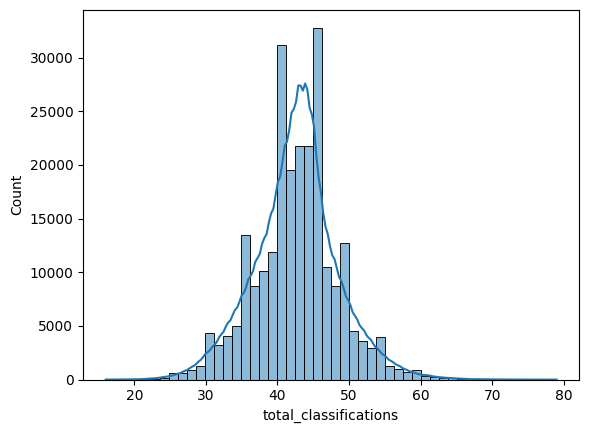

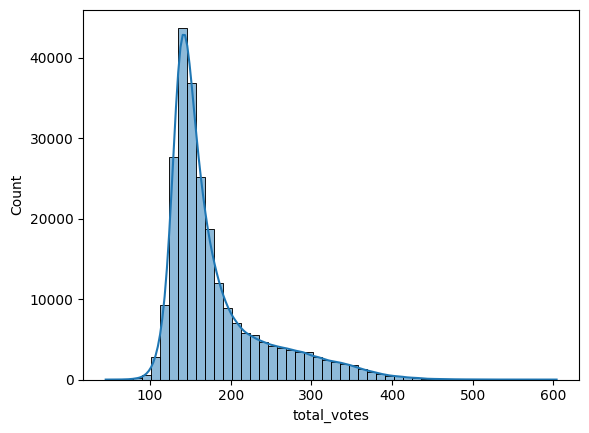

In [25]:
# Visualizar distribución de participación de voluntarios
# - total_classifications: número de voluntarios que clasificaron la galaxia
# - total_votes: votos totales asignados a la clase mayoritaria
# Alta participación indica mayor confianza en la clasificación
sns.histplot(data=df, x='total_classifications', kde=True, bins=50)
plt.title('Distribución de Clasificaciones por Voluntarios')
plt.show()

sns.histplot(data=df, x='total_votes', kde=True, bins=50)
plt.title('Distribución de Votos para Clase Mayoritaria')
plt.show()

/tmp/ipykernel_68978/3074162129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


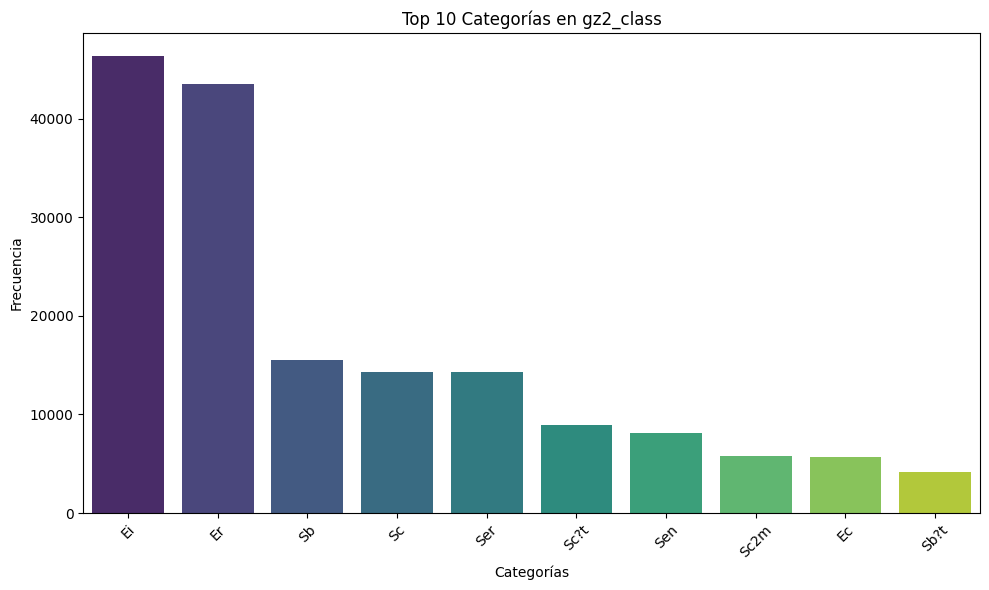

In [26]:
# Visualizar las 10 clasificaciones morfológicas más frecuentes
# El catálogo tiene ~680 categorías granulares; el modelo reducirá a 4 clases principales
top_categories = df['gz2class'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('Top 10 Categorías Morfológicas (Galaxy Zoo 2)')
plt.xlabel('Categoría (gz2class)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Construcción del Dataset Etiquetado (4 Clases)

Simplificamos las ~680 categorías en 4 clases balanceadas usando los
**scores debiased** (columnas `*_debiased`) del catálogo Galaxy Zoo 2.
Estos scores son probabilidades de consenso corregidas por sesgo de selección.

Reglas de clasificación con umbral principal `THRESH = 0.9`:

| Clase | Condición |
|---|---|
| elliptical | `a01_smooth_debiased ≥ 0.9` |
| spiral | `a02_features_debiased ≥ 0.9` AND `a05_no_edgeon ≥ 0.9` AND `a08_spiral ≥ 0.9` |
| edge_on | `a02_features_debiased ≥ 0.9` AND `a04_edgeon ≥ 0.9` |
| merger | `a14_odd ≥ 0.7` AND `a24_merger ≥ 0.7` (umbral más bajo por rareza) |

In [27]:
# Seleccionar columnas para el dataset reducido
columnas_interes = ['dr7objid', 'gz2class', 'total_classifications', 'total_votes', 'asset_id']
df_final = df[columnas_interes]

In [28]:
# Inspeccionar galaxias clasificadas como 'A' (artefactos/estrellas)
# Estas serán excluidas del dataset final por no ser galaxias reales
df_final.loc[df_final['gz2class'].str.startswith('A')]

,dr7objid,gz2class,total_classifications,total_votes,asset_id
30,587738067813924971,A,47,158,257980
194,588017702398263355,A,46,133,270509
709,587734950206636108,A,42,99,77434
4524,588017603611262986,A,45,146,211199
4600,587725041702469675,A,45,84,4984
6136,587746213744410684,A,43,58,189390
7987,587742013274325004,A,42,79,162962
9174,588017110759243820,A,47,160,269560
11570,588017605752586284,A,41,103,212731
13640,587736479199920221,A,42,112,89685


In [29]:
# Agregar columna con ruta de imagen para cada galaxia
df_final['path'] = df_final['asset_id'].apply(
    lambda x: f'../data/images/{x}.jpg'
)
df_final.head()

/tmp/ipykernel_68978/3841026248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['path'] = df_final['asset_id'].apply(lambda x: f'../data/images/{x}.jpg')


,dr7objid,gz2class,total_classifications,total_votes,asset_id,path
0,588017703996096547,SBb?t,44,349,217750,../data/images/217750.jpg
1,587738569780428805,Ser,45,185,112436,../data/images/112436.jpg
2,587735695913320507,Sc+t,46,372,86566,../data/images/86566.jpg
3,587742775634624545,SBc(r),45,289,182364,../data/images/182364.jpg
4,587732769983889439,Ser,49,210,252712,../data/images/252712.jpg


In [30]:
# Ver todas las categorías morfológicas disponibles (~680 tipos)
# Estas serán simplificadas en 4 clases con thresholds en celdas siguientes
sorted(df.gz2class.unique())

['A',
 'Ec',
 'Ec(d)',
 'Ec(i)',
 'Ec(l)',
 'Ec(m)',
 'Ec(o)',
 'Ec(r)',
 'Ec(u)',
 'Ei',
 'Ei(d)',
 'Ei(i)',
 'Ei(l)',
 'Ei(m)',
 'Ei(o)',
 'Ei(r)',
 'Ei(u)',
 'Er',
 'Er(d)',
 'Er(i)',
 'Er(l)',
 'Er(m)',
 'Er(o)',
 'Er(r)',
 'Er(u)',
 'SBa',
 'SBa(i)',
 'SBa(m)',
 'SBa(o)',
 'SBa(r)',
 'SBa+l',
 'SBa+t',
 'SBa1l',
 'SBa1l(d)',
 'SBa1l(i)',
 'SBa1l(m)',
 'SBa1m',
 'SBa1m(d)',
 'SBa1m(i)',
 'SBa1m(m)',
 'SBa1t',
 'SBa1t(o)',
 'SBa2l',
 'SBa2l(d)',
 'SBa2l(i)',
 'SBa2l(m)',
 'SBa2l(o)',
 'SBa2l(r)',
 'SBa2m',
 'SBa2m(i)',
 'SBa2m(m)',
 'SBa2m(o)',
 'SBa2m(r)',
 'SBa2t',
 'SBa2t(l)',
 'SBa2t(o)',
 'SBa2t(r)',
 'SBa?l',
 'SBa?m',
 'SBa?m(o)',
 'SBa?m(r)',
 'SBa?t',
 'SBa?t(o)',
 'SBa?t(r)',
 'SBb',
 'SBb(d)',
 'SBb(i)',
 'SBb(l)',
 'SBb(m)',
 'SBb(o)',
 'SBb(r)',
 'SBb(u)',
 'SBb+l',
 'SBb+m',
 'SBb+m(i)',
 'SBb+m(m)',
 'SBb+t',
 'SBb+t(d)',
 'SBb+t(i)',
 'SBb+t(m)',
 'SBb+t(r)',
 'SBb1l',
 'SBb1l(d)',
 'SBb1l(i)',
 'SBb1l(m)',
 'SBb1l(o)',
 'SBb1l(r)',
 'SBb1m',
 'SBb1m(d)',
 'SBb1m(i)'

In [31]:
# Revisar distribución de todas las clasificaciones
# Ei (elíptica inclinada) y Er (elíptica redonda) son las más frecuentes
print(df_final['gz2class'].value_counts().reset_index())

     gz2class  count
0          Ei  46375
1          Er  43476
2          Sb  15548
3          Sc  14317
4         Ser  14300
..        ...    ...
674   Sd3l(o)      1
675     SBd4m      1
676  SBa2t(o)      1
677      Sa+l      1
678  SBb3m(o)      1

[679 rows x 2 columns]


### 3. Visualización de Muestras por Clase

In [32]:
def visualizar_sample_clases(df, clase, n=5, random_state=42):
    """
    Mostrar una grilla de imágenes de galaxias de una categoría gz2class específica.

    Args:
        df: DataFrame con columnas 'gz2class' y 'path'
        clase: Prefijo de clase a visualizar (ej: 'Ei', 'Sb', 'Sc')
        n: Número de imágenes a mostrar
        random_state: Semilla para reproducibilidad
    """
    if clase not in df['gz2class'].unique():
        print(f'Clase "{clase}" no encontrada en el DataFrame.')
        return
    if n > len(df[df['gz2class'].str.startswith(clase)]):
        disponibles = len(df[df['gz2class'].str.startswith(clase)])
        print(f'Solo hay {disponibles} muestras disponibles para la clase "{clase}".')
        return

    sample = df[df['gz2class'].str.startswith(clase)].sample(n=n, random_state=random_state)

    num_cols = 3
    num_rows = (n + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))

    if num_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for idx, (galaxy_class, path) in enumerate(sample[['gz2class', 'path']].itertuples(index=False)):
        img = Image.open(path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'Clase: {galaxy_class}', fontsize=12)
        axes[idx].axis('off')

    # Ocultar subplots vacíos si n no es múltiplo de num_cols
    for idx in range(len(sample), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [33]:
def visualizar_sample_etiquetas(df, etiqueta, n=5, random_state=42):
    """
    Mostrar una grilla de imágenes de galaxias de una clase simplificada (label).

    Args:
        df: DataFrame con columnas 'label' y 'path'
        etiqueta: Clase simplificada ('elliptical', 'spiral', 'edge_on', 'merger')
        n: Número de imágenes a mostrar
        random_state: Semilla para reproducibilidad
    """
    if etiqueta not in df['label'].unique():
        print(f'Etiqueta "{etiqueta}" no encontrada en el DataFrame.')
        return
    if n > len(df[df['label'].str.startswith(etiqueta)]):
        disponibles = len(df[df['label'].str.startswith(etiqueta)])
        print(f'Solo hay {disponibles} muestras disponibles para "{etiqueta}".')
        return

    sample = df[df['label'].str.startswith(etiqueta)].sample(n=n, random_state=random_state)

    num_cols = 3
    num_rows = (n + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))

    if num_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for idx, (galaxy_class, path) in enumerate(sample[['label', 'path']].itertuples(index=False)):
        img = Image.open(path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'Etiqueta: {galaxy_class}', fontsize=12)
        axes[idx].axis('off')

    for idx in range(len(sample), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Visualizar ejemplos de una clase granular específica (prefijo gz2class)
# 'Ei(i)': elíptica inclinada con característica 'i' — galaxia representativa del catálogo
visualizar_sample_clases(df_final, 'Ei(i)', n=20, random_state=3)

In [35]:
# Listar columnas con scores debiased disponibles
# Estas son las probabilidades de consenso corregidas por sesgo de selección,
# y son las que se usan para construir las clases morfológicas puras
debiased_cols = [col for col in df.columns if 'debiased' in col]
print(f"Columnas debiased disponibles: {len(debiased_cols)}")
debiased_cols

['t01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't02_edgeon_a04_yes_debiased',
 't02_edgeon_a05_no_debiased',
 't03_bar_a06_bar_debiased',
 't03_bar_a07_no_bar_debiased',
 't04_spiral_a08_spiral_debiased',
 't04_spiral_a09_no_spiral_debiased',
 't05_bulge_prominence_a10_no_bulge_debiased',
 't05_bulge_prominence_a11_just_noticeable_debiased',
 't05_bulge_prominence_a12_obvious_debiased',
 't05_bulge_prominence_a13_dominant_debiased',
 't06_odd_a14_yes_debiased',
 't06_odd_a15_no_debiased',
 't07_rounded_a16_completely_round_debiased',
 't07_rounded_a17_in_between_debiased',
 't07_rounded_a18_cigar_shaped_debiased',
 't08_odd_feature_a19_ring_debiased',
 't08_odd_feature_a20_lens_or_arc_debiased',
 't08_odd_feature_a21_disturbed_debiased',
 't08_odd_feature_a22_irregular_debiased',
 't08_odd_feature_a23_other_debiased',
 't08_odd_feature_a24_merger_debiased',
 't08_odd_featu

In [36]:
# Comparar distribución de clases con distintos thresholds de confianza
# Threshold más alto = menos galaxias pero mayor certeza de clasificación
# Threshold más bajo = más galaxias pero mayor contaminación entre clases

import pandas as pd
import numpy as np

thresholds = [0.5, 0.6, 0.7, 0.8]

def get_counts(df, thresh):
    """Cuenta galaxias por clase para un threshold de confianza dado."""
    is_artifact = df['t01_smooth_or_features_a03_star_or_artifact_debiased'] >= thresh

    is_merger = (
        (df['t06_odd_a14_yes_debiased'] >= thresh) &
        (df['t08_odd_feature_a24_merger_debiased'] >= thresh)
    )
    is_edge_on = (
        (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= thresh) &
        (df['t02_edgeon_a04_yes_debiased'] >= thresh)
    )
    is_spiral = (
        (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= thresh) &
        (df['t02_edgeon_a05_no_debiased'] >= thresh) &
        (df['t04_spiral_a08_spiral_debiased'] >= thresh)
    )
    is_elliptical = df['t01_smooth_or_features_a01_smooth_debiased'] >= thresh
    uncertain = ~is_artifact & ~is_merger & ~is_edge_on & ~is_spiral & ~is_elliptical

    # Clases 'puras': cumplen su condición y no tienen señal conflictiva de merger
    pure_merger     = is_merger & ~is_artifact
    pure_edge_on    = is_edge_on & ~is_merger & ~is_artifact
    pure_spiral     = is_spiral  & ~is_merger & ~is_artifact
    pure_elliptical = is_elliptical & ~is_merger & ~is_artifact

    return {
        'elliptical': pure_elliptical.sum(),
        'spiral':     pure_spiral.sum(),
        'edge_on':    pure_edge_on.sum(),
        'merger':     pure_merger.sum(),
        'uncertain':  uncertain.sum(),
        'total_usable': (pure_elliptical | pure_spiral | pure_edge_on | pure_merger).sum()
    }

print(f"{'Clase':<14}", end="")
for t in thresholds:
    print(f"  thresh={t}", end="")
print()
print("─" * 58)

results = {t: get_counts(df, t) for t in thresholds}

for clase in ['elliptical', 'spiral', 'edge_on', 'merger', 'total_usable', 'uncertain']:
    print(f"{clase:<14}", end="")
    for t in thresholds:
        val = results[t][clase]
        print(f"  {val:>9,}", end="")
    print()

gz2class
Ei       46375
Er       43476
Sb       15548
Sc       14317
Ser      14300
Sc?t      8933
Sen       8074
Sc2m      5828
Ec        5634
Sb?t      4125
Sc2t      3925
SBb       3433
Sb2m      2951
SBc2m     2792
SBb2m     2564
Sc?m      2564
Sb(r)     2460
Er(o)     2104
Sb2t      2050
SBc       1864
Name: count, dtype: int64


In [37]:
# Explorar configuraciones con thresholds distintos por clase
# Mergers requieren un threshold más bajo porque son galxias raras en el catálogo
# Thresholds más altos en clases principales reduce contaminación

configs = {
    'uniforme_0.7' : {'elliptical': 0.7, 'spiral': 0.7, 'edge_on': 0.7, 'merger': 0.7},
    'mixto_0.8/0.7': {'elliptical': 0.8, 'spiral': 0.8, 'edge_on': 0.8, 'merger': 0.7},
    'mixto_0.9/0.7': {'elliptical': 0.9, 'spiral': 0.9, 'edge_on': 0.9, 'merger': 0.7},
}

def get_pure_sets(df, t_ell, t_spi, t_edg, t_mer):
    """Cuenta galaxias puras por clase con thresholds independientes por tipo."""
    is_artifact = df['t01_smooth_or_features_a03_star_or_artifact_debiased'] >= 0.7

    is_merger = (
        (df['t06_odd_a14_yes_debiased'] >= t_mer) &
        (df['t08_odd_feature_a24_merger_debiased'] >= t_mer)
    )
    is_edge_on = (
        (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= t_edg) &
        (df['t02_edgeon_a04_yes_debiased'] >= t_edg)
    )
    is_spiral = (
        (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= t_spi) &
        (df['t02_edgeon_a05_no_debiased'] >= t_spi) &
        (df['t04_spiral_a08_spiral_debiased'] >= t_spi)
    )
    is_elliptical = df['t01_smooth_or_features_a01_smooth_debiased'] >= t_ell
    uncertain = ~is_artifact & ~is_merger & ~is_edge_on & ~is_spiral & ~is_elliptical

    return {
        'elliptical': (is_elliptical & ~is_merger & ~is_artifact).sum(),
        'spiral':     (is_spiral     & ~is_merger & ~is_artifact).sum(),
        'edge_on':    (is_edge_on    & ~is_merger & ~is_artifact).sum(),
        'merger':     (is_merger                  & ~is_artifact).sum(),
        'uncertain':  uncertain.sum(),
    }

print(f"{'Clase':<14}", end="")
for cfg_name in configs:
    print(f"  {cfg_name:>15}", end="")
print()
print("─" * 62)

all_results = {}
for cfg_name, thresholds in configs.items():
    all_results[cfg_name] = get_pure_sets(df, **{
        't_ell': thresholds['elliptical'],
        't_spi': thresholds['spiral'],
        't_edg': thresholds['edge_on'],
        't_mer': thresholds['merger'],
    })

for clase in ['elliptical', 'spiral', 'edge_on', 'merger', 'uncertain']:
    print(f"{clase:<14}", end="")
    for cfg_name in configs:
        val = all_results[cfg_name][clase]
        print(f"  {val:>15,}", end="")
    print()

Clase           thresh=0.5  thresh=0.6  thresh=0.7  thresh=0.8
──────────────────────────────────────────────────────────
elliptical        100,958     76,421     50,884     27,063
spiral             62,250     49,427     38,489     28,667
edge_on            23,479     18,353     13,549      8,767
merger              6,049      3,067      1,265        385
total_usable      189,273    147,065    104,186     64,882
uncertain          54,043     96,318    139,233    178,547


In [38]:
# Construir dataset final balanceado con configuración elegida:
# - THRESH_MAIN = 0.9 para elliptical, spiral, edge_on
# - THRESH_MERGER = 0.7 para mergers (más laxo, son galaxias raras)
# - CAP = 1,265 galaxias por clase (limitado por la clase minoritaria: mergers)

THRESH_MAIN = 0.9
THRESH_MERGER = 0.7
CAP = 1_265    # Tamaño de la clase minoritaria (merger) — define el balance
SEED = 3

# Definir condiciones de pertenencia a cada clase
is_artifact = df['t01_smooth_or_features_a03_star_or_artifact_debiased'] >= 0.5

is_merger = (
    (df['t06_odd_a14_yes_debiased'] >= THRESH_MERGER) &
    (df['t08_odd_feature_a24_merger_debiased'] >= THRESH_MERGER)
)
is_edge_on = (
    (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= THRESH_MAIN) &
    (df['t02_edgeon_a04_yes_debiased'] >= THRESH_MAIN)
)
is_spiral = (
    (df['t01_smooth_or_features_a02_features_or_disk_debiased'] >= THRESH_MAIN) &
    (df['t02_edgeon_a05_no_debiased'] >= THRESH_MAIN) &
    (df['t04_spiral_a08_spiral_debiased'] >= THRESH_MAIN)
)
is_elliptical = df['t01_smooth_or_features_a01_smooth_debiased'] >= THRESH_MAIN

# Extraer subconjuntos puros: cada galaxy pertenece a exactamente una clase
pure_merger     = df[ is_merger                          & ~is_artifact]
pure_edge_on    = df[ is_edge_on    & ~is_merger         & ~is_artifact]
pure_spiral     = df[ is_spiral     & ~is_merger         & ~is_artifact]
pure_elliptical = df[ is_elliptical & ~is_merger         & ~is_artifact]

# Submuestreo estratificado y balanceado
subsets = {
    'elliptical': pure_elliptical,
    'spiral':     pure_spiral,
    'edge_on':    pure_edge_on,
    'merger':     pure_merger,
}

frames = []
print(f"{'Clase':<14} {'Disponibles':>12}  {'Sampled':>8}  {'Threshold':>10}")
print("─" * 50)

for label, subset in subsets.items():
    n = min(len(subset), CAP)
    t = THRESH_MERGER if label == 'merger' else THRESH_MAIN
    sample = subset.sample(n=n, random_state=SEED).copy()
    sample['label'] = label
    frames.append(sample)
    print(f"  {label:<12} {len(subset):>12,}  {n:>8,}  {t:>10.1f}")

df_labels_final = pd.concat(frames).reset_index(drop=True)

print("─" * 50)
print(f"  {'TOTAL':<12} {'':>12}  {len(df_labels_final):>8,}")

Clase              uniforme_0.7    mixto_0.8/0.7    mixto_0.9/0.7
──────────────────────────────────────────────────────────────
elliptical               50,884           27,047            7,511
spiral                   38,489           28,524           18,060
edge_on                  13,549            8,763            4,084
merger                    1,265            1,265            1,265
uncertain               139,233          177,820          212,499


In [39]:
# Unir dataset etiquetado con df_final para agregar columnas path y gz2class
df_test = pd.merge(
    df_final,
    df_labels_final[['dr7objid', 'label', 'ra', 'dec']],
    on='dr7objid',
    how='inner'
)

Clase           Disponibles   Sampled   Threshold
──────────────────────────────────────────────────
  elliptical          7,511     1,265         0.9
  spiral             18,060     1,265         0.9
  edge_on             4,084     1,265         0.9
  merger              1,265     1,265         0.7
──────────────────────────────────────────────────
  TOTAL                         5,060


In [40]:
# Exportar dataset final con etiquetas simplificadas
# Este CSV es el punto de entrada para el entrenamiento del modelo EfficientNet
OUTPUT_PATH = '/home/irving/Documentos/Diplomado/Modulo 5/Sideral/data/gz2_labels_clean.csv'
df_test.to_csv(OUTPUT_PATH, index=False)

print(f"\n  ✓ Guardado: gz2_labels_clean.csv")
print(f"  Clases: {sorted(df_test['label'].unique())}")

In [41]:
# Verificar visualmente las imágenes del dataset final
# Mostrar muestra de galaxias elípticas etiquetadas
visualizar_sample_etiquetas(df_test, 'elliptical', n=120, random_state=5)


  ✓ Guardado: gz2_labels_clean.csv
  Clases: ['edge_on', 'elliptical', 'merger', 'spiral']


In [ ]:
# Verificar que los archivos exportados son legibles y tienen las columnas correctas
archivo_clases = pd.read_csv('/home/irving/Documentos/Diplomado/Modulo 5/Sideral/data/gz2_labels_clean.csv')
archivo_coords = pd.read_csv('/home/irving/Documentos/Diplomado/Modulo 5/Sideral/data/labels.csv')

In [43]:
# Confirmar 4 clases en el dataset exportado
archivo_clases.label.unique()

In [44]:
# Vista general del dataset final
archivo_coords

array(['edge_on', 'merger', 'spiral', 'elliptical'], dtype=object)

In [45]:
archivo_coords

,specobjid,dr8objid,dr7objid,ra,dec,rastring,decstring,sample,gz2class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,t01_smooth_or_features_a01_smooth_weight,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a01_smooth_weighted_fraction,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a01_smooth_flag,t01_smooth_or_features_a02_features_or_disk_count,t01_smooth_or_features_a02_features_or_disk_weight,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a02_features_or_disk_weighted_fraction,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a02_features_or_disk_flag,t01_smooth_or_features_a03_star_or_artifact_count,t01_smooth_or_features_a03_star_or_artifact_weight,t01_smooth_or_features_a03_star_or_artifact_fraction,t01_smooth_or_features_a03_star_or_artifact_weighted_fraction,t01_smooth_or_features_a03_star_or_artifact_debiased,t01_smooth_or_features_a03_star_or_artifact_flag,t02_edgeon_a04_yes_count,t02_edgeon_a04_yes_weight,t02_edgeon_a04_yes_fraction,t02_edgeon_a04_yes_weighted_fraction,t02_edgeon_a04_yes_debiased,t02_edgeon_a04_yes_flag,t02_edgeon_a05_no_count,t02_edgeon_a05_no_weight,t02_edgeon_a05_no_fraction,t02_edgeon_a05_no_weighted_fraction,t02_edgeon_a05_no_debiased,t02_edgeon_a05_no_flag,t03_bar_a06_bar_count,t03_bar_a06_bar_weight,t03_bar_a06_bar_fraction,t03_bar_a06_bar_weighted_fraction,t03_bar_a06_bar_debiased,t03_bar_a06_bar_flag,t03_bar_a07_no_bar_count,t03_bar_a07_no_bar_weight,t03_bar_a07_no_bar_fraction,t03_bar_a07_no_bar_weighted_fraction,t03_bar_a07_no_bar_debiased,t03_bar_a07_no_bar_flag,t04_spiral_a08_spiral_count,t04_spiral_a08_spiral_weight,t04_spiral_a08_spiral_fraction,t04_spiral_a08_spiral_weighted_fraction,t04_spiral_a08_spiral_debiased,t04_spiral_a08_spiral_flag,t04_spiral_a09_no_spiral_count,t04_spiral_a09_no_spiral_weight,t04_spiral_a09_no_spiral_fraction,t04_spiral_a09_no_spiral_weighted_fraction,t04_spiral_a09_no_spiral_debiased,t04_spiral_a09_no_spiral_flag,t05_bulge_prominence_a10_no_bulge_count,t05_bulge_prominence_a10_no_bulge_weight,t05_bulge_prominence_a10_no_bulge_fraction,t05_bulge_prominence_a10_no_bulge_weighted_fraction,t05_bulge_prominence_a10_no_bulge_debiased,t05_bulge_prominence_a10_no_bulge_flag,t05_bulge_prominence_a11_just_noticeable_count,t05_bulge_prominence_a11_just_noticeable_weight,t05_bulge_prominence_a11_just_noticeable_fraction,t05_bulge_prominence_a11_just_noticeable_weighted_fraction,t05_bulge_prominence_a11_just_noticeable_debiased,t05_bulge_prominence_a11_just_noticeable_flag,t05_bulge_prominence_a12_obvious_count,t05_bulge_prominence_a12_obvious_weight,t05_bulge_prominence_a12_obvious_fraction,t05_bulge_prominence_a12_obvious_weighted_fraction,t05_bulge_prominence_a12_obvious_debiased,t05_bulge_prominence_a12_obvious_flag,t05_bulge_prominence_a13_dominant_count,t05_bulge_prominence_a13_dominant_weight,t05_bulge_prominence_a13_dominant_fraction,t05_bulge_prominence_a13_dominant_weighted_fraction,t05_bulge_prominence_a13_dominant_debiased,t05_bulge_prominence_a13_dominant_flag,t06_odd_a14_yes_count,t06_odd_a14_yes_weight,t06_odd_a14_yes_fraction,t06_odd_a14_yes_weighted_fraction,t06_odd_a14_yes_debiased,t06_odd_a14_yes_flag,t06_odd_a15_no_count,t06_odd_a15_no_weight,t06_odd_a15_no_fraction,t06_odd_a15_no_weighted_fraction,t06_odd_a15_no_debiased,t06_odd_a15_no_flag,t07_rounded_a16_completely_round_count,t07_rounded_a16_completely_round_weight,t07_rounded_a16_completely_round_fraction,t07_rounded_a16_completely_round_weighted_fraction,t07_rounded_a16_completely_round_debiased,t07_rounded_a16_completely_round_flag,t07_rounded_a17_in_between_count,t07_rounded_a17_in_between_weight,t07_rounded_a17_in_between_fraction,t07_rounded_a17_in_between_weighted_fraction,t07_rounded_a17_in_between_debiased,t07_rounded_a17_in_between_flag,t07_rounded_a18_cigar_shaped_count,t07_rounded_a18_cigar_shaped_weight,t07_rounded_a18_cigar_shaped_fraction,t07_rounded_a18_cigar_sh